# Homework - KNN

In this exercise, you’ll implement the KNN algorithm yourself in multiple forms, and will analyze its performance. 

I leave it to you to think about and define the API of the functions you write - the inputs and outputs. I am also not providing you with data to train/test the classifier. You should create your own datasets using Scikit-learn’s make_classification function (http://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html)

## 1. Implement the KNN algorithm
Implement the kNN algorithm in python as a function.  
Use the Euclidean distance as the distance metric between data points.

In [2]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

class KNNClassifier:
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def _distance(self, x):
        # Euclidean distance
        return np.linalg.norm(self.X_train - x, axis=1)

    def _predict_one(self, x):
        distances = self._distance(x)

        # indices of k nearest neighbors
        nn_idx = np.argsort(distances)[:self.n_neighbors]

        # labels of nearest neighbors
        nn_labels = self.y_train[nn_idx]

        # majority vote
        values, counts = np.unique(nn_labels, return_counts=True)
        return values[np.argmax(counts)]

    def predict(self, X):
        return np.apply_along_axis(self._predict_one, 1, X)


# Create dataset
X, y = make_classification(
    n_samples=500,
    n_features=4,
    n_informative=2,
    n_redundant=0,
    random_state=42
)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
knn = KNNClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict
predictions = knn.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8700


## 2. Passing a function as a parameter
Change your code so that it accepts function as one of the input parameters, and uses this function to calculate the distance between points. Run your code with both a function for Euclidean distance and for cosine distance.

In [3]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Distance functions

def euclidean_distance(X_train, x):
    return np.linalg.norm(X_train - x, axis=1)


def cosine_distance(X_train, x):
    similarity = cosine_similarity(X_train, x.reshape(1, -1)).flatten()
    return 1 - similarity


class FlexibleKNN:
    def __init__(self, n_neighbors=5, distance_function=euclidean_distance):
        self.n_neighbors = n_neighbors
        self.distance_function = distance_function

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def _predict_one(self, x):
        distances = self.distance_function(self.X_train, x)
        nn_idx = np.argsort(distances)[:self.n_neighbors]
        nn_labels = self.y_train[nn_idx]

        values, counts = np.unique(nn_labels, return_counts=True)
        return values[np.argmax(counts)]

    def predict(self, X):
        return np.apply_along_axis(self._predict_one, 1, X)


# Euclidean distance example
knn_euclidean = FlexibleKNN(
    n_neighbors=5,
    distance_function=euclidean_distance
)

knn_euclidean.fit(X_train, y_train)
pred_euclidean = knn_euclidean.predict(X_test)

print("Euclidean Accuracy:", accuracy_score(y_test, pred_euclidean))


# Cosine distance example
knn_cosine = FlexibleKNN(
    n_neighbors=5,
    distance_function=cosine_distance
)

knn_cosine.fit(X_train, y_train)
pred_cosine = knn_cosine.predict(X_test)

print("Cosine Accuracy:", accuracy_score(y_test, pred_cosine))

Euclidean Accuracy: 0.87
Cosine Accuracy: 0.87


## 3. Object Oriented Programming in Python
Implement the KNN algorithm using a class, that follows the Scikit-learn API of init, fit and predict methods.  
More information about object oriented programming in Python is in these links:
1. https://realpython.com/python3-object-oriented-programming/
1. http://www.tutorialspoint.com/python/python_classes_objects.htm
1. https://www.youtube.com/watch?v=ZDa-Z5JzLYM
1. https://docs.python.org/3/tutorial/classes.html


In [4]:
class KNNClassifierOOP:
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        return self

    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def _predict_single(self, x):
        distances = [
            self._euclidean_distance(x, x_train)
            for x_train in self.X_train
        ]

        k_indices = np.argsort(distances)[:self.n_neighbors]
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        values, counts = np.unique(k_nearest_labels, return_counts=True)
        return values[np.argmax(counts)]

    def predict(self, X):
        return np.array([self._predict_single(x) for x in X])


# Example usage
model = KNNClassifierOOP(n_neighbors=3)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.89


## 4. Decision boundary
Given a dataset you create with 2 classes, plot the decision boundary of a KNN algorithm in 2D for k = 3 and k = 15.

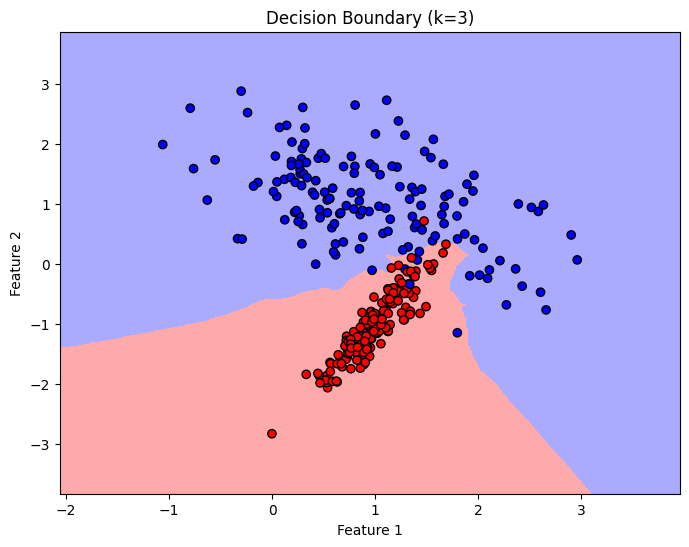

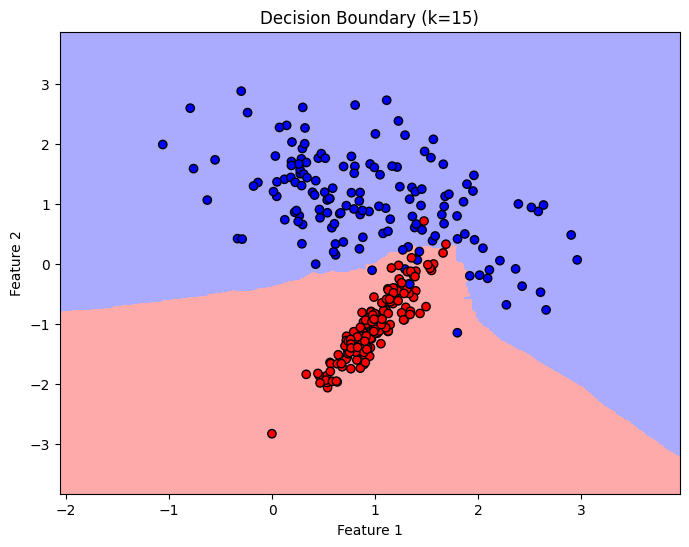

In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Create 2D dataset
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


def plot_decision_boundary(model, X, y, title):
    h = 0.02

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#0000FF'])

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=cmap_light)

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap=cmap_bold,
        edgecolor='k'
    )

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()


# k = 3
knn3 = KNNClassifier(n_neighbors=3)
knn3.fit(X_train, y_train)
plot_decision_boundary(knn3, X, y, "Decision Boundary (k=3)")


# k = 15
knn15 = KNNClassifier(n_neighbors=15)
knn15.fit(X_train, y_train)
plot_decision_boundary(knn15, X, y, "Decision Boundary (k=15)")

## 5. Learning Curve
Plot a learning curve for the kNN algorithm - change the number of points used as true labels in range 10 to 1000, and compare the algorithm’s performance on the set from question 4.  
For subsets of the data points, average the results of several runs.  
Plot the overall accuracy, precision, recall and f1 scores.  
Use k = 5.
These links provide additional information on the learning curve:
1. https://www.dataquest.io/blog/learning-curves-machine-learning/
1. http://www.ritchieng.com/machinelearning-learning-curve/


c:\Users\Yonatan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


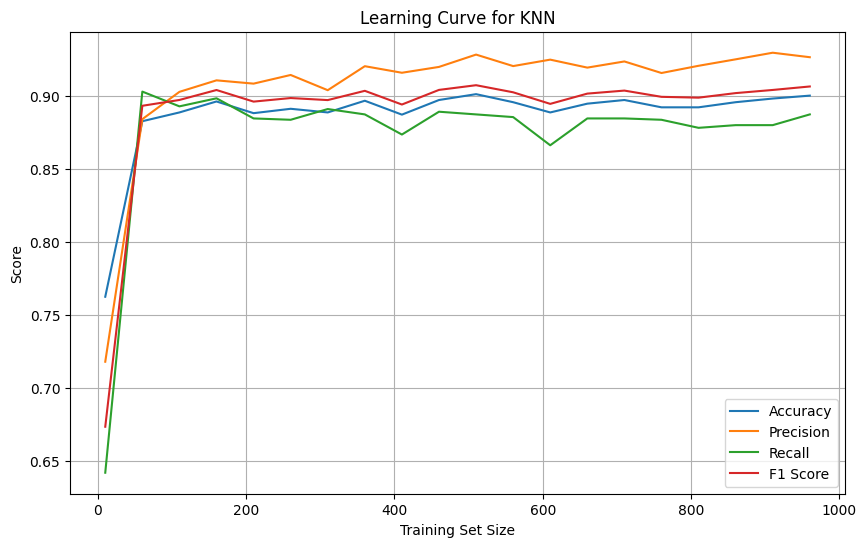

In [6]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# Dataset
X, y = make_classification(
    n_samples=2000,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

sizes = np.arange(10, 1001, 50)

accuracy_list = []
precision_list = []
recall_list = []
f1_list = []


for size in sizes:
    acc_runs = []
    prec_runs = []
    rec_runs = []
    f1_runs = []

    for _ in range(5):
        idx = np.random.choice(len(X_train), size=size, replace=False)

        X_subset = X_train[idx]
        y_subset = y_train[idx]

        knn = KNNClassifier(n_neighbors=5)
        knn.fit(X_subset, y_subset)

        predictions = knn.predict(X_test)

        acc_runs.append(accuracy_score(y_test, predictions))
        prec_runs.append(precision_score(y_test, predictions))
        rec_runs.append(recall_score(y_test, predictions))
        f1_runs.append(f1_score(y_test, predictions))

    accuracy_list.append(np.mean(acc_runs))
    precision_list.append(np.mean(prec_runs))
    recall_list.append(np.mean(rec_runs))
    f1_list.append(np.mean(f1_runs))


# Plot
plt.figure(figsize=(10, 6))

plt.plot(sizes, accuracy_list, label='Accuracy')
plt.plot(sizes, precision_list, label='Precision')
plt.plot(sizes, recall_list, label='Recall')
plt.plot(sizes, f1_list, label='F1 Score')

plt.xlabel("Training Set Size")
plt.ylabel("Score")
plt.title("Learning Curve for KNN")
plt.legend()
plt.grid(True)
plt.show()

## 6. Effect of k
Plot the performance of the KNN algorithm for different values of k. Plot the f1 metric.


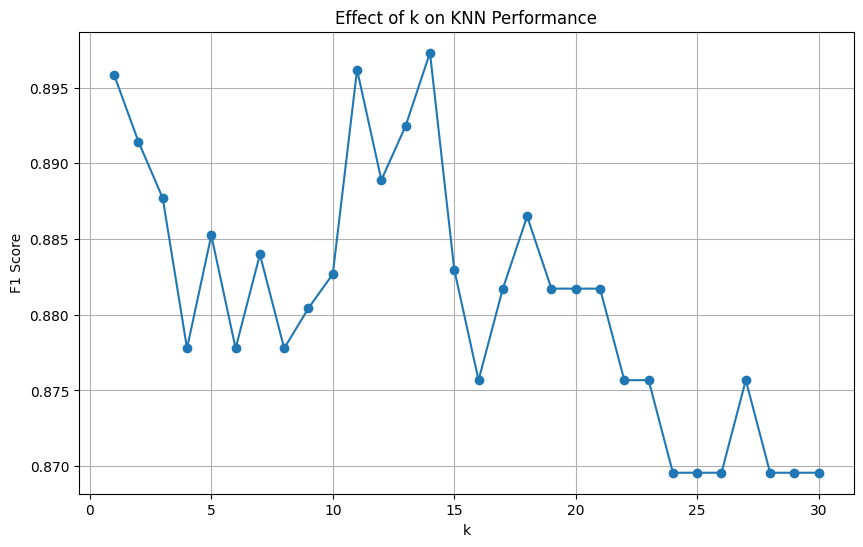

In [7]:
k_values = range(1, 31)
f1_scores = []

# Dataset
X, y = make_classification(
    n_samples=1000,
    n_features=4,
    n_informative=2,
    n_redundant=0,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


for k in k_values:
    knn = KNNClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    predictions = knn.predict(X_test)

    score = f1_score(y_test, predictions)
    f1_scores.append(score)


plt.figure(figsize=(10, 6))
plt.plot(k_values, f1_scores, marker='o')

plt.xlabel("k")
plt.ylabel("F1 Score")
plt.title("Effect of k on KNN Performance")
plt.grid(True)
plt.show()

## 7. Precision vs. Recall
We’ve talked in class about how in different scenarios we might prefer to maximize precision or recall. How would you prefer one over the other in the KNN algorithm?

let remind ourselves:
Higher precision → fewer false positives,
Higher recall → fewer false negatives.
 In KNN, we can prefer precision or recall mainly by changing the value of k or by adjusting the decision threshold.

I didnt implement it in the original classifier, but the threshold can be adjusted in this example of the predict_one method:

In [ ]:
def _predict_one(self, x):
    distances = self._distance(x)

    nn_idx = np.argsort(distances)[:self.n_neighbors]
    nn_labels = self.y_train[nn_idx]

    positive_ratio = np.mean(nn_labels)

    threshold = 0.7

    if positive_ratio > threshold:
        return 1
    else:
        return 0